# Loeuf CV Pipeline — Measurement Engine

Output ตาม **cv_schema_table_loeuf** (17-layer JSON schema)

| Phase | Blocks | Section |
|---|---|---|
| Phase 1 | MT → M/VQ/B/A → metric (9 blocks) → D/VF/CF/VZ | §1–3 |
| Phase 2 | + AGG / TRE / PAT / SUM | §4 |
| — | GAS delivery | §5 |

> **Section 1 รันได้ทันทีโดยไม่ต้องมีวิดีโอ** (synthetic landmarks) —
> มีคลิปจริงให้ตั้ง `VIDEO_PATH` ใน §3

In [1]:
import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from loeuf_cv import PipelineConfig, StrokePipeline, SessionPipeline

config = PipelineConfig(
    dominant_side="right",
    subject_height_cm=172.0,     # C1 calibration px→cm
    session_id="sess-20260702-01",
    # gas_endpoint_url="https://script.google.com/macros/s/.../exec",
)
pipeline = StrokePipeline(config)
print("thresholds: auto_accept ≥", config.auto_accept_threshold,
      "| coach_review ≥", config.coach_review_threshold)

thresholds: auto_accept ≥ 0.85 | coach_review ≥ 0.6


## §1 Phase 1 บน Synthetic Landmarks

จำลอง forehand มุมหลัง → ได้ stroke object ครบทุก layer
(M / VQ / B / A / metrics / derived / VF / CF / VZ)

In [2]:
from loeuf_cv.synthetic import synthetic_forehand

ts = synthetic_forehand(fps=30, duration_s=3.0)
stroke = pipeline.process_timeseries(ts, "FH")

kf = stroke["keyframes"]
print(f"{'keyframe':26s} {'frame':>6s} {'time (ms)':>10s}  detected")
for name, k in kf.items():
    t = f"{k['timestamp_ms']:.1f}" if k["timestamp_ms"] is not None else "—"
    print(f"{name:26s} {str(k['frame_index'] or '—'):>6s} {t:>10s}  {k['detected']}")

root, cf = stroke["stroke_root"], stroke["confidence_flag"]
print(f"\nA7 detection_status : {root['detection_status']}")
print(f"A8 is_clean_stroke  : {root['is_clean_stroke']}")
print(f"CF1 confidence      : {cf['pose_estimation_confidence']}")
print(f"A9 action           : {root['stroke_recommended_action']}")

keyframe                    frame  time (ms)  detected
unit_turn                      38      633.3  True
backswing_peak                 69     1150.0  True
impact                         78     1298.7  True
follow_through_peak           112     1866.7  True
ready_position_restored       139     2316.7  True

A7 detection_status : valid
A8 is_clean_stroke  : True
CF1 confidence      : 0.94
A9 action           : auto_accept


/var/folders/f6/fywm6dlx0hd71c4xn4ns3bkw0000gn/T/ipykernel_11189/1159118439.py:28: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/f6/fywm6dlx0hd71c4xn4ns3bkw0000gn/T/ipykernel_11189/1159118439.py:28: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/f6/fywm6dlx0hd71c4xn4ns3bkw0000gn/T/ipykernel_11189/1159118439.py:28: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/panpan/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/panpan/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.c

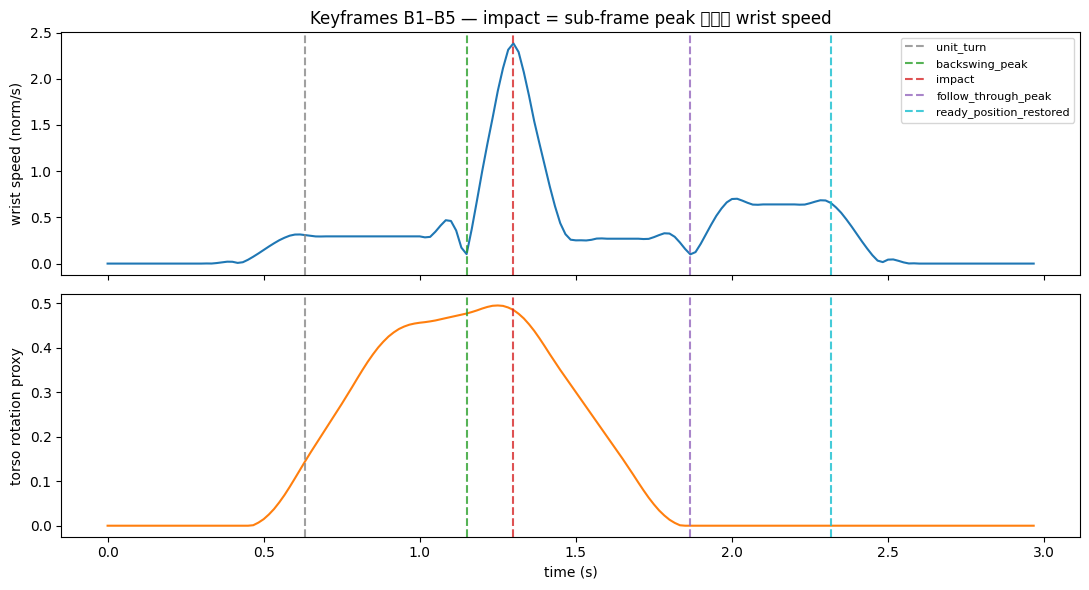

VZ1 wrist_path: 44 points (REQUIRED)  eg. [{'frame': 69, 'x': 0.74, 'y': 0.599}, {'frame': 70, 'x': 0.738, 'y': 0.596}]


In [3]:
# สัญญาณที่ขับ keyframe detection + VZ1 wrist_path
from loeuf_cv.smoothing import smooth_timeseries
from loeuf_cv.kinematics import dominant, speed, torso_rotation_proxy
from loeuf_cv.config import KEYFRAME_NAMES
from loeuf_cv.resample import resample_to_target_fps

rs, _ = resample_to_target_fps(ts, config)
smoothed = smooth_timeseries(rs, config)
side = dominant(config.dominant_side)
t_s = smoothed.timestamps_ms / 1000.0
wrist_speed = speed(np.nan_to_num(smoothed.landmarks[:, side["wrist"], :2]), smoothed.timestamps_ms)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t_s, wrist_speed, color="tab:blue")
axes[0].set_ylabel("wrist speed (norm/s)")
axes[1].plot(t_s, torso_rotation_proxy(smoothed), color="tab:orange")
axes[1].set_ylabel("torso rotation proxy")
axes[1].set_xlabel("time (s)")

colors = dict(zip(KEYFRAME_NAMES, ["#888", "#2ca02c", "#d62728", "#9467bd", "#17becf"]))
for name, k in stroke["keyframes"].items():
    if k["detected"]:
        for ax in axes:
            ax.axvline(k["timestamp_ms"] / 1000.0, color=colors[name],
                       linestyle="--", alpha=0.8, label=name)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Keyframes B1–B5 — impact = sub-frame peak ของ wrist speed")
plt.tight_layout(); plt.show()

wp = stroke["visualization"]["wrist_path"]
print(f"VZ1 wrist_path: {len(wp)} points (REQUIRED)  eg. {wp[:2]}")

In [4]:
# metric blocks + derived enums ครบตาม schema
print(json.dumps({"metrics": stroke["metrics"], "derived": stroke["derived"]},
                 ensure_ascii=False, indent=1))

{
 "metrics": {
  "body": {
   "body_height_cm": 172.0,
   "arm_span_cm": 172.0,
   "shoulder_rotation_at_unit_turn_deg": -5.66,
   "shoulder_rotation_at_impact_deg": 18.14,
   "hip_rotation_at_unit_turn_deg": -3.97,
   "hip_rotation_at_impact_deg": 13.04,
   "shoulder_rotation_normalized_pct": 18.14,
   "shoulder_hip_separation_at_impact_deg": 5.1,
   "head_still_at_contact": true
  },
  "arm": {
   "follow_through_angle_deg": 148.26,
   "backswing_depth_deg": -44.98
  },
  "timing": {
   "backswing_duration_ms": 516.67,
   "forward_swing_duration_ms": 148.72,
   "total_swing_duration_ms": 665.39,
   "tempo_ratio": 3.47,
   "rhythm_class": "slow"
  },
  "contact": {
   "contact_height_cm": 109.31,
   "contact_distance_from_body_cm": 16.59,
   "swing_path_angle_deg": 24.31
  },
  "movement": {
   "split_step_detected": false,
   "split_step_timing_ms": null,
   "footwork_distance_cm": 0.32,
   "movement_speed_mps": 0.0,
   "stance_width_at_impact_cm": 38.94,
   "stance_angle_deg": 0.0,

## §2 fps Normalization (M4/M5)

input < 60fps → resample เป็น 60fps (`velocity_normalized: true`)
KN fields จากต้นทาง 30fps ติด `low_confidence` เพราะ velocity fidelity
จำกัดที่ fps จริง

In [5]:
for fps in (30, 60):
    s = pipeline.process_timeseries(synthetic_forehand(fps=fps), "FH")
    m = s["stroke_metadata"]
    kn_vis = s["visibility_flag"]["shoulder_rotation_velocity_deg_s"]
    print(f"{fps}fps → velocity_normalized={m['velocity_normalized']}"
          f" ({m['normalization_method']}) | KN visibility: {kn_vis}")

30fps → velocity_normalized=True (resampled_to_60fps) | KN visibility: low_confidence
60fps → velocity_normalized=False (none) | KN visibility: visible


## §3 Phase 1 กับคลิปจริง

ตั้ง `VIDEO_PATH` แล้วรัน — cell จะ skip ถ้ายังไม่มีไฟล์

In [6]:
VIDEO_PATH = str(REPO_ROOT / "data" / "sample_fh.mp4")   # ← แก้ตรงนี้
STROKE_TYPE = "FH"

real_result = None
if Path(VIDEO_PATH).exists():
    real_result = pipeline.process_video(VIDEO_PATH, STROKE_TYPE)
    out_path = Path(VIDEO_PATH).with_suffix(".json")
    out_path.write_text(json.dumps(real_result, ensure_ascii=False, indent=2))
    st = real_result["strokes"][0]
    print(f"saved → {out_path}")
    print(json.dumps(st["stroke_root"], indent=1))
else:
    print(f"(skip) ยังไม่มีไฟล์ {VIDEO_PATH}")

(skip) ยังไม่มีไฟล์ /Users/panpan/Tennis cv/data/sample_fh.mp4


In [7]:
# เฟรม ณ keyframes พร้อม pose overlay (รันเมื่อมีคลิปจริง)
if real_result is not None:
    import cv2
    import mediapipe as mp

    st = real_result["strokes"][0]
    kf_frames = {n: k["frame_index"] for n, k in st["keyframes"].items() if k["detected"]}
    cap = cv2.VideoCapture(VIDEO_PATH)
    fig, axes = plt.subplots(1, len(kf_frames), figsize=(4 * len(kf_frames), 5))
    pose = mp.solutions.pose.Pose(static_image_mode=True)
    for ax, (name, fidx) in zip(np.atleast_1d(axes), kf_frames.items()):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ok, frame = cap.read()
        if not ok:
            continue
        res = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if res.pose_landmarks:
            mp.solutions.drawing_utils.draw_landmarks(
                frame, res.pose_landmarks, mp.solutions.pose.POSE_CONNECTIONS)
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{name}\nframe {fidx}", fontsize=9)
        ax.axis("off")
    pose.close(); cap.release()
    plt.tight_layout(); plt.show()
else:
    print("(skip)")

(skip)


## §4 Phase 2 — Session + AGG / TRE / PAT / SUM

action spotting หา stroke จากวิดีโอยาว → Phase 1 core ต่อ window
→ aggregation ฝั่ง CV (ตาม schema ใหม่)
(เดโม synthetic session 4 strokes; วิดีโอจริงใช้
`SessionPipeline(config).process_video("match.mp4")` บรรทัดเดียว)

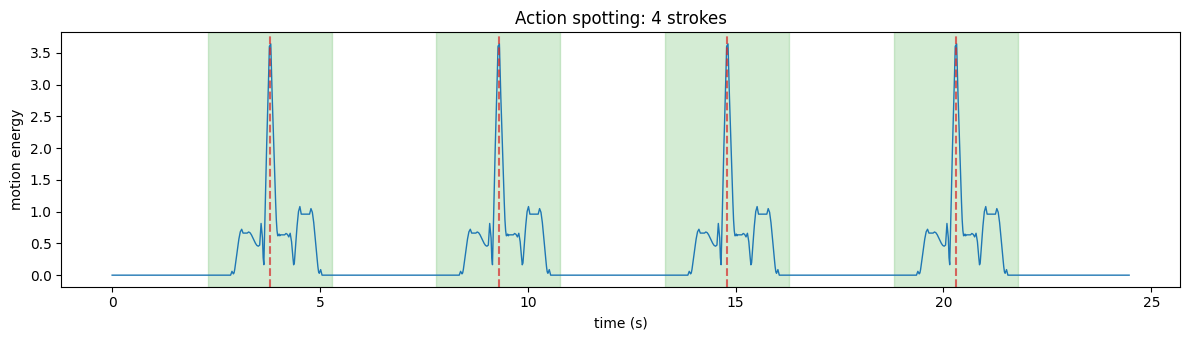

In [8]:
from loeuf_cv.synthetic import synthetic_session
from loeuf_cv.action_spotting import spot_strokes
from loeuf_cv.kinematics import motion_energy
from loeuf_cv.config import UPPER_BODY
from loeuf_cv.aggregation import (build_aggregated_metric, build_trend,
                                  build_pattern, build_session_summary)

session_ts, norm = resample_to_target_fps(synthetic_session(fps=30, n_strokes=4), config)
windows = spot_strokes(session_ts, config)
energy = motion_energy(session_ts, UPPER_BODY)
t_s = session_ts.timestamps_ms / 1000.0

plt.figure(figsize=(12, 3.5))
plt.plot(t_s, energy, color="tab:blue", lw=1)
for w in windows:
    plt.axvspan(t_s[w.start_frame], t_s[w.end_frame - 1], alpha=0.2, color="tab:green")
    plt.axvline(t_s[w.peak_frame], color="tab:red", linestyle="--", alpha=0.7)
plt.title(f"Action spotting: {len(windows)} strokes")
plt.xlabel("time (s)"); plt.ylabel("motion energy")
plt.tight_layout(); plt.show()

In [9]:
strokes = []
for i, w in enumerate(windows):
    strokes.append(pipeline.process_timeseries(
        session_ts.slice(w.start_frame, w.end_frame), "FH",
        stroke_index=i + 1, window_offset_ms=w.offset_ms,
        window_offset_frames=w.start_frame, pre_resampled=norm))

trend = build_trend(strokes)
print("AGG:", json.dumps(build_aggregated_metric(strokes), indent=1))
print("TRE:", json.dumps(trend, indent=1))
print("PAT:", json.dumps(build_pattern(strokes), ensure_ascii=False, indent=1))
print("SUM:", json.dumps(build_session_summary(strokes, trend, config), indent=1))

AGG: [
 {
  "stroke_type": "FH",
  "stroke_count": 4,
  "shoulder_rotation_mean_deg": 18.14,
  "shoulder_rotation_sd_deg": 0.0,
  "hip_rotation_mean_deg": 13.04,
  "tempo_ratio_mean": 3.47,
  "tempo_ratio_sd": 0.0,
  "contact_height_mean_cm": 109.31,
  "swing_path_angle_mean_deg": 24.31,
  "racket_head_speed_mean_mps": 7.74,
  "split_step_rate_pct": 0.0,
  "recovery_time_mean_ms": 450.0
 }
]
TRE: {
 "window_method": "thirds",
 "shoulder_rotation_trend": "stable",
 "tempo_ratio_trend": "stable",
 "recovery_time_trend": "stable",
 "split_step_rate_trend": "stable",
 "consistency_score": 1.0,
 "fatigue_flag": false,
 "fatigue_onset_stroke_index": null
}
PAT: {
 "dominant_stroke_type": "FH",
 "stroke_sequence": [
  "FH",
  "FH",
  "FH",
  "FH"
 ],
 "groundstroke_sequence_detected": true,
 "serve_fault_rate_pct": null,
 "backhand_avoidance_flag": null
}
SUM: {
 "session_quality": "excellent",
 "primary_issue": null,
 "highlight_stroke_index": 1,
 "recommended_drill_tag": null,
 "coach_flag"

## §5 GAS Delivery

In [10]:
from loeuf_cv.gas_client import post_to_gas, save_json
from loeuf_cv.schema import build_output, build_session_metadata

phase1_json = build_output(build_session_metadata(ts, config), [stroke])
demo_path = str(REPO_ROOT / "example_fh_output.json")
save_json(phase1_json, demo_path)
print(f"saved → {demo_path}")

# ส่งเข้า GAS (uncomment เมื่อได้ URL):
# print(post_to_gas(phase1_json, config.gas_endpoint_url))

saved → /Users/panpan/Tennis cv/example_fh_output.json


## Notes / TBC ที่ต้อง confirm กับลูกค้า

- **Per-field confidence**: นิยามบอก per-field แต่ sample JSON ไม่มี block → ยังไม่ส่ง (รอ confirm)
- **Precision**: ตอนนี้ปัด 2 ตำแหน่ง (ตามตาราง type) — ขัดกับ note "ส่งเต็ม precision"
- **C19/C20**: implement เป็น `ready(B5) − follow_through(B4)` (label ใน doc สลับ)
- **C31**: ใช้ hand index keypoint แทน racket (ไม่มี racket detector)
- **Rotation sign** (+/− เทียบ net) และ threshold ทุกตัวที่ doc mark TBC → validate Phase 0 กับคลิปจริง
- **body_height_cm**: ใช้ส่วนสูงผู้เล่นเป็น calibration input — ไม่ระบุ → 170cm + low_confidence